In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
#read the dataset
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


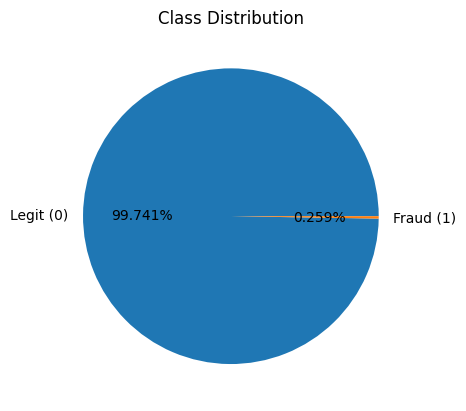

['Legit (0)', 'Fraud (1)']
[41574   108]


In [3]:
# visualising the dataset to analyse the disparity in fraudalent transactions.
#getting unique class labels (0 and 1)

labels = ['Legit (0)', 'Fraud (1)']

#count the number of transactions
sizes = df.Class.value_counts().values

#pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.3f%%')
ax.set_title('Class Distribution')
plt.show()

print(labels)
print(sizes)

In [4]:
#becuase a the data is unbalanced- performing undersampling now
fraud_df=df[df['Class']==1]     #fraud rows
legit_df=df[df['Class']==0]

print(f"The number of fraud cases:{len(fraud_df)}")
print(f"The number of legit cases:{len(legit_df)}")

#ramdomly picking legit datasets same amt as fraud cases.
legit_sample = legit_df.sample(n=len(fraud_df), random_state=42)
#grouping them
balanced_data = pd.concat([fraud_df, legit_sample])
balanced_data = balanced_data.sample(frac=1, random_state=42)

print(f"\nBalanced dataset size: {len(balanced_data)}")
print(balanced_data['Class'].value_counts())

The number of fraud cases:108
The number of legit cases:41574

Balanced dataset size: 216
Class
0.0    108
1.0    108
Name: count, dtype: int64


In [5]:
# X = features (the clues), y = target (fraud or not)
X = balanced_data.drop('Class', axis=1)
y = balanced_data['Class']

# Split into 80% train, 20% test
# random_state=42 ensures getting the same split every time we run this
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 172
Testing samples:  44


In [6]:
# Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# .fit() is where the actual training happens
dt_model.fit(X_train, y_train)

# .predict() uses the learned tree to make predictions on new data (test set)
dt_predictions = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_predictions))
print("\nDetailed Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 0.9318181818181818

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.95      0.90      0.92        20
         1.0       0.92      0.96      0.94        24

    accuracy                           0.93        44
   macro avg       0.93      0.93      0.93        44
weighted avg       0.93      0.93      0.93        44



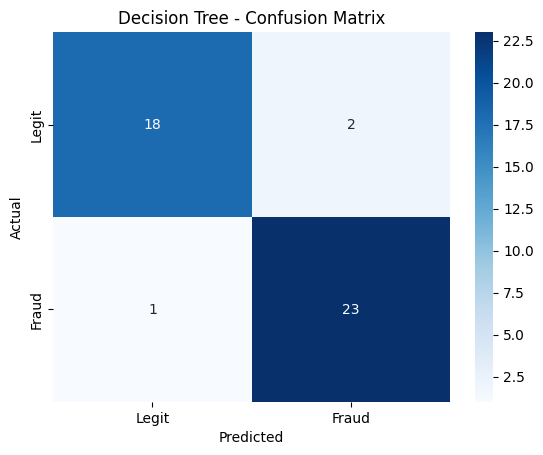

In [7]:
# A confusion matrix shows exactly where the model was right and wrong
cm = confusion_matrix(y_test, dt_predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree - Confusion Matrix')
plt.show()

In [9]:
#training the SVM now.
# kernel='rbf' means it can draw curved boundaries, not just straight lines
svm_model = SVC(kernel='rbf', random_state=42)

svm_model.fit(X_train, y_train)

# Predict on the test set
svm_predictions = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, svm_predictions))
print("\nDetailed Report:")
print(classification_report(y_test, svm_predictions))

SVM Accuracy: 0.7045454545454546

Detailed Report:
              precision    recall  f1-score   support

         0.0       0.64      0.80      0.71        20
         1.0       0.79      0.62      0.70        24

    accuracy                           0.70        44
   macro avg       0.71      0.71      0.70        44
weighted avg       0.72      0.70      0.70        44



In [10]:
#here SVM'S performed worse comapred to desicion trees due to small data and svm unable to find out best fit line.

In [11]:
#Checking our model now
# Taking 10 random transactions from the test set
sample_10 = X_test.iloc[:10]
actual_10 = y_test.iloc[:10]
predictions_10 = dt_model.predict(sample_10)

# Display a comparison table
import pandas as pd
results = pd.DataFrame({
    'Actual':    ['FRAUD ' if x == 1 else 'LEGIT ' for x in actual_10],
    'Predicted': ['FRAUD ' if x == 1 else 'LEGIT ' for x in predictions_10],
})
results['Correct?'] = results['Actual'] == results['Predicted']
print(results)

   Actual Predicted  Correct?
0  FRAUD     FRAUD       True
1  FRAUD     FRAUD       True
2  FRAUD     FRAUD       True
3  FRAUD     FRAUD       True
4  LEGIT     LEGIT       True
5  LEGIT     LEGIT       True
6  LEGIT     LEGIT       True
7  FRAUD     FRAUD       True
8  FRAUD     FRAUD       True
9  FRAUD     FRAUD       True
